In [1]:
# ============================================================
# BASELINE ATTRITION MODEL
# Enterprise HR AI Platform
# ============================================================

import pandas as pd
import numpy as np

from pathlib import Path

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score
)

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
# ============================================================
# PROJECT PATH SETUP
# ============================================================

CURRENT_DIR = Path.cwd()

PROJECT_ROOT = CURRENT_DIR.parent

FEATURE_ENGINEERED_PATH = (
    PROJECT_ROOT /
    "data" /
    "feature_engineered"
)

MODEL_PATH = (
    PROJECT_ROOT /
    "models"
)

MODEL_PATH.mkdir(
    parents=True,
    exist_ok=True
)

print("Current Directory:")
print(CURRENT_DIR)

print("\nProject Root:")
print(PROJECT_ROOT)

print("\nFeature Engineered Data:")
print(FEATURE_ENGINEERED_PATH)

print("\nModels Directory:")
print(MODEL_PATH)


Current Directory:
C:\Users\Shubham\Desktop\enterprise_hr_ai\notebooks

Project Root:
C:\Users\Shubham\Desktop\enterprise_hr_ai

Feature Engineered Data:
C:\Users\Shubham\Desktop\enterprise_hr_ai\data\feature_engineered

Models Directory:
C:\Users\Shubham\Desktop\enterprise_hr_ai\models


In [3]:


# ============================================================
# LOAD EMPLOYEE FEATURE DATA
# ============================================================

employee_file = (
    FEATURE_ENGINEERED_PATH /
    "employee_features.csv"
)

employee_df = pd.read_csv(
    employee_file
)

print("Employee feature dataset loaded successfully.")

print(
    f"\nDataset Shape: {employee_df.shape}"
)

display(
    employee_df.head()
)

Employee feature dataset loaded successfully.

Dataset Shape: (1470, 47)


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,ExperienceGroup,CompanyTenureGroup,OverallSatisfactionScore,SatisfactionCategory,OverTimeRisk,LongCommuteRisk,LowIncomeRisk,FrequentJobChangeRisk,AttritionRiskScore,AttritionRiskCategory
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,6-10 Years,6-10 Years,2.00,Low Satisfaction,High Risk,Lower Risk,Lower Risk,High Risk,5,High Risk
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,6-10 Years,6-10 Years,3.00,Medium Satisfaction,Lower Risk,Lower Risk,Lower Risk,Lower Risk,0,Low Risk
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,6-10 Years,0-1 Year,3.00,Medium Satisfaction,High Risk,Lower Risk,High Risk,High Risk,4,High Risk
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,6-10 Years,6-10 Years,3.25,High Satisfaction,High Risk,Lower Risk,High Risk,Lower Risk,3,Medium Risk
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,6-10 Years,2-3 Years,2.50,Medium Satisfaction,Lower Risk,Lower Risk,Lower Risk,High Risk,3,Medium Risk


In [4]:
# ============================================================
# ATTRITION TARGET INSPECTION
# ============================================================

print("ATTRITION TARGET DISTRIBUTION")
print("=" * 70)

print(
    employee_df["Attrition"]
    .value_counts()
)

print("\nAttrition Percentage:")

display(
    (
        employee_df["Attrition"]
        .value_counts(normalize=True)
        .mul(100)
        .round(2)
        .to_frame(name="Percentage")
    )
)

ATTRITION TARGET DISTRIBUTION
No     1233
Yes     237
Name: Attrition, dtype: int64

Attrition Percentage:


,Percentage
No,83.88
Yes,16.12


In [5]:
# ============================================================
# CREATE BINARY ATTRITION TARGET
# ============================================================

employee_df["AttritionTarget"] = (
    employee_df["Attrition"]
    .map({
        "No": 0,
        "Yes": 1
    })
)

print("AttritionTarget created.")

print("\nTarget values:")

display(
    employee_df["AttritionTarget"]
    .value_counts()
    .sort_index()
    .to_frame(name="Employee Count")
)

AttritionTarget created.

Target values:


,Employee Count
0,1233
1,237


In [6]:
# ============================================================
# SELECT BASELINE MODEL FEATURES
# ============================================================

model_features = [
    "Age",
    "OverTime",
    "JobSatisfaction",
    "MonthlyIncome",
    "YearsAtCompany",
    "WorkLifeBalance",
    "TotalWorkingYears",
    "YearsInCurrentRole",
    "YearsSinceLastPromotion",
    "YearsWithCurrManager",
    "JobLevel",
    "JobInvolvement",
    "EnvironmentSatisfaction",
    "RelationshipSatisfaction",
    "DistanceFromHome",
    "NumCompaniesWorked",
    "PercentSalaryHike",
    "StockOptionLevel",
    "TrainingTimesLastYear",
    "BusinessTravel",
    "Department",
    "EducationField",
    "JobRole",
    "MaritalStatus",
    "Gender",
    "IncomePerYearExperience",
    "CompanyTenureRatio",
    "PromotionWaitRatio",
    "OverallSatisfactionScore",
    "CareerStabilityScore"
]

available_features = [
    column
    for column in model_features
    if column in employee_df.columns
]

missing_features = [
    column
    for column in model_features
    if column not in employee_df.columns
]

print("MODEL FEATURES")
print("=" * 70)

print(f"Requested Features: {len(model_features)}")
print(f"Available Features: {len(available_features)}")

print("\nAvailable:")
print(available_features)

if missing_features:
    print("\nMissing:")
    print(missing_features)

MODEL FEATURES
Requested Features: 30
Available Features: 26

Available:
['Age', 'OverTime', 'JobSatisfaction', 'MonthlyIncome', 'YearsAtCompany', 'WorkLifeBalance', 'TotalWorkingYears', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager', 'JobLevel', 'JobInvolvement', 'EnvironmentSatisfaction', 'RelationshipSatisfaction', 'DistanceFromHome', 'NumCompaniesWorked', 'PercentSalaryHike', 'StockOptionLevel', 'TrainingTimesLastYear', 'BusinessTravel', 'Department', 'EducationField', 'JobRole', 'MaritalStatus', 'Gender', 'OverallSatisfactionScore']

Missing:
['IncomePerYearExperience', 'CompanyTenureRatio', 'PromotionWaitRatio', 'CareerStabilityScore']


In [7]:
# ============================================================
# CREATE FEATURES AND TARGET
# ============================================================

X = employee_df[
    available_features
].copy()

y = employee_df[
    "AttritionTarget"
].copy()

print("FEATURE MATRIX")
print("=" * 70)

print(
    f"X Shape: {X.shape}"
)

print(
    f"y Shape: {y.shape}"
)

print("\nTarget Distribution:")

display(
    y.value_counts()
    .sort_index()
    .to_frame(name="Count")
)


FEATURE MATRIX
X Shape: (1470, 26)
y Shape: (1470,)

Target Distribution:


,Count
0,1233
1,237


In [8]:
# ============================================================
# IDENTIFY FEATURE TYPES
# ============================================================

numeric_features = X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = X.select_dtypes(
    include=["object", "category", "bool"]
).columns.tolist()

print("NUMERICAL FEATURES")
print("=" * 70)

print(numeric_features)

print(
    f"\nTotal Numerical Features: "
    f"{len(numeric_features)}"
)

print("\nCATEGORICAL FEATURES")
print("=" * 70)

print(categorical_features)

print(
    f"\nTotal Categorical Features: "
    f"{len(categorical_features)}"
)

NUMERICAL FEATURES
['Age', 'JobSatisfaction', 'MonthlyIncome', 'YearsAtCompany', 'WorkLifeBalance', 'TotalWorkingYears', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager', 'JobLevel', 'JobInvolvement', 'EnvironmentSatisfaction', 'RelationshipSatisfaction', 'DistanceFromHome', 'NumCompaniesWorked', 'PercentSalaryHike', 'StockOptionLevel', 'TrainingTimesLastYear', 'OverallSatisfactionScore']

Total Numerical Features: 19

CATEGORICAL FEATURES
['OverTime', 'BusinessTravel', 'Department', 'EducationField', 'JobRole', 'MaritalStatus', 'Gender']

Total Categorical Features: 7


In [9]:
# ============================================================
# PREPROCESSING PIPELINE
# ============================================================

numeric_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="median"
            )
        ),
        (
            "scaler",
            StandardScaler()
        )
    ]
)

categorical_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="most_frequent"
            )
        ),
        (
            "encoder",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            )
        )
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            numeric_pipeline,
            numeric_features
        ),
        (
            "categorical",
            categorical_pipeline,
            categorical_features
        )
    ]
)

print("Preprocessing pipeline created successfully.")

Preprocessing pipeline created successfully.


In [10]:
# ============================================================
# TRAIN TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

print("TRAIN / TEST SPLIT")
print("=" * 70)

print(
    f"Training Samples: {len(X_train)}"
)

print(
    f"Testing Samples: {len(X_test)}"
)

print("\nTraining Target Distribution:")

display(
    y_train.value_counts()
    .sort_index()
    .to_frame(name="Count")
)

print("\nTesting Target Distribution:")

display(
    y_test.value_counts()
    .sort_index()
    .to_frame(name="Count")
)

TRAIN / TEST SPLIT
Training Samples: 1176
Testing Samples: 294

Training Target Distribution:


,Count
0,986
1,190



Testing Target Distribution:


,Count
0,247
1,47


In [28]:
baseline_model = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "model",
            LogisticRegression(
                max_iter=1000,
                random_state=42
            )
        )
    ]
)

In [29]:
# ============================================================
# TRAIN BASELINE MODEL
# ============================================================

print("Training Logistic Regression model...")

baseline_model.fit(
    X_train,
    y_train
)

print("✓ Model training completed successfully.")

Training Logistic Regression model...
✓ Model training completed successfully.


In [30]:
# ============================================================
# GENERATE BASELINE PREDICTIONS
# ============================================================

y_pred = baseline_model.predict(
    X_test
)

y_probability = baseline_model.predict_proba(
    X_test
)[:, 1]

print("Predictions generated successfully.")

print(
    f"\nPredictions: {len(y_pred)}"
)

print(
    f"Probability Range: "
    f"{y_probability.min():.4f} - "
    f"{y_probability.max():.4f}"
)

Predictions generated successfully.

Predictions: 294
Probability Range: 0.0006 - 0.9761


In [31]:
# ============================================================
# CLASSIFICATION REPORT
# ============================================================

print("BASELINE MODEL CLASSIFICATION REPORT")
print("=" * 80)

print(
    classification_report(
        y_test,
        y_pred,
        target_names=[
            "Retained",
            "Left"
        ],
        digits=4
    )
)

BASELINE MODEL CLASSIFICATION REPORT
              precision    recall  f1-score   support

    Retained     0.8876    0.9595    0.9222       247
        Left     0.6296    0.3617    0.4595        47

    accuracy                         0.8639       294
   macro avg     0.7586    0.6606    0.6908       294
weighted avg     0.8464    0.8639    0.8482       294



In [32]:
# ============================================================
# BASELINE MODEL METRICS
# ============================================================

baseline_precision = precision_score(
    y_test,
    y_pred,
    zero_division=0
)

baseline_recall = recall_score(
    y_test,
    y_pred,
    zero_division=0
)

baseline_f1 = f1_score(
    y_test,
    y_pred,
    zero_division=0
)

baseline_roc_auc = roc_auc_score(
    y_test,
    y_probability
)

baseline_metrics = pd.DataFrame({
    "Metric": [
        "Precision",
        "Recall",
        "F1 Score",
        "ROC-AUC"
    ],
    
    "Score": [
        round(baseline_precision, 4),
        round(baseline_recall, 4),
        round(baseline_f1, 4),
        round(baseline_roc_auc, 4)
    ]
})

print("BASELINE MODEL EVALUATION")
print("=" * 70)

display(baseline_metrics)

BASELINE MODEL EVALUATION


,Metric,Score
0,Precision,0.6296
1,Recall,0.3617
2,F1 Score,0.4595
3,ROC-AUC,0.8182


In [33]:
# ============================================================
# CONFUSION MATRIX
# ============================================================

conf_matrix = confusion_matrix(
    y_test,
    y_pred
)

confusion_df = pd.DataFrame(
    conf_matrix,
    index=[
        "Actual Retained",
        "Actual Left"
    ],
    columns=[
        "Predicted Retained",
        "Predicted Left"
    ]
)

print("CONFUSION MATRIX")
print("=" * 70)

display(confusion_df)

CONFUSION MATRIX


,Predicted Retained,Predicted Left
Actual Retained,237,10
Actual Left,30,17


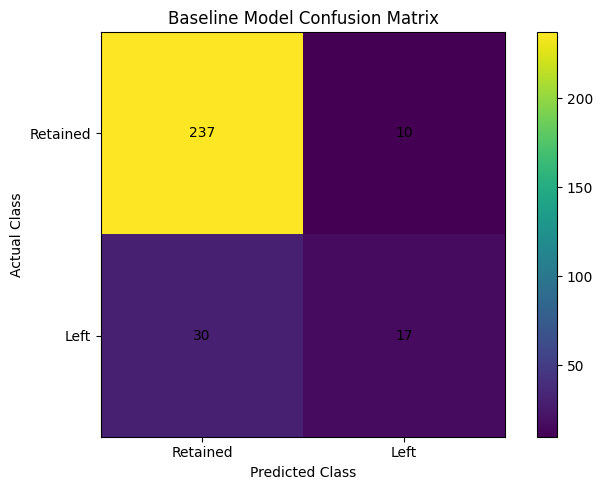

In [34]:
# ============================================================
# CONFUSION MATRIX VISUALIZATION
# ============================================================

plt.figure(figsize=(7, 5))

plt.imshow(
    conf_matrix,
    interpolation="nearest"
)

plt.title(
    "Baseline Model Confusion Matrix"
)

plt.xlabel(
    "Predicted Class"
)

plt.ylabel(
    "Actual Class"
)

plt.xticks(
    [0, 1],
    ["Retained", "Left"]
)

plt.yticks(
    [0, 1],
    ["Retained", "Left"]
)

for i in range(2):
    for j in range(2):
        plt.text(
            j,
            i,
            conf_matrix[i, j],
            ha="center",
            va="center"
        )

plt.colorbar()

plt.tight_layout()

plt.show()

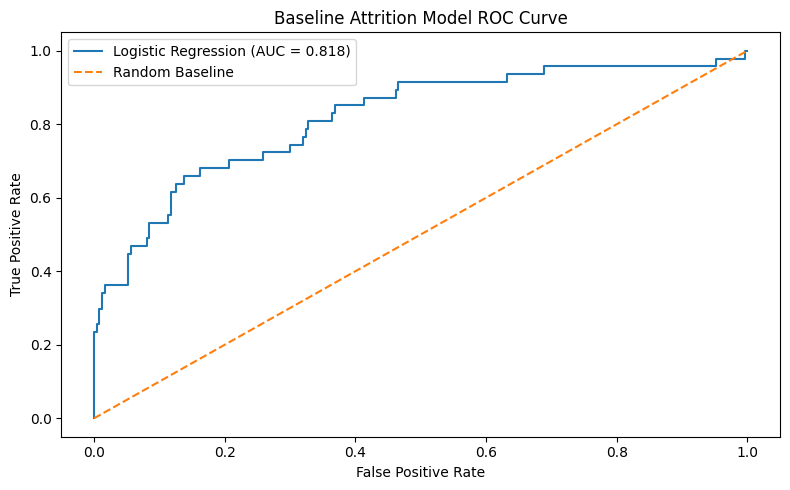

In [35]:
# ============================================================
# ROC CURVE
# ============================================================

from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(
    y_test,
    y_probability
)

plt.figure(figsize=(8, 5))

plt.plot(
    fpr,
    tpr,
    label=f"Logistic Regression (AUC = {baseline_roc_auc:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Baseline"
)

plt.title(
    "Baseline Attrition Model ROC Curve"
)

plt.xlabel(
    "False Positive Rate"
)

plt.ylabel(
    "True Positive Rate"
)

plt.legend()

plt.tight_layout()

plt.show()

In [36]:
# ============================================================
# CREATE TEST PREDICTION DATASET
# ============================================================

test_predictions = X_test.copy()

test_predictions["ActualAttrition"] = y_test.values

test_predictions["PredictedAttrition"] = y_pred

test_predictions["AttritionProbability"] = (
    y_probability.round(4)
)

def assign_risk_level(probability):
    
    if probability >= 0.70:
        return "HIGH"
    
    elif probability >= 0.40:
        return "MEDIUM"
    
    else:
        return "LOW"


test_predictions["RiskLevel"] = (
    test_predictions["AttritionProbability"]
    .apply(assign_risk_level)
)

print("TEST PREDICTION DATASET CREATED")

display(
    test_predictions[
        [
            "ActualAttrition",
            "PredictedAttrition",
            "AttritionProbability",
            "RiskLevel"
        ]
    ].head(15)
)

TEST PREDICTION DATASET CREATED


,ActualAttrition,PredictedAttrition,AttritionProbability,RiskLevel
1061,0,0,0.0793,LOW
891,0,0,0.0034,LOW
456,0,0,0.1337,LOW
922,0,0,0.0069,LOW
69,1,0,0.2778,LOW
1164,0,0,0.2540,LOW
406,0,0,0.0065,LOW
1330,0,0,0.0162,LOW
1232,0,0,0.0052,LOW
1311,0,0,0.1283,LOW


In [37]:
# ============================================================
# BASELINE PREDICTED RISK DISTRIBUTION
# ============================================================

risk_distribution = (
    test_predictions["RiskLevel"]
    .value_counts()
    .reindex(
        ["HIGH", "MEDIUM", "LOW"],
        fill_value=0
    )
    .to_frame(
        name="Employee Count"
    )
)

print("PREDICTED RISK DISTRIBUTION")
print("=" * 70)

display(risk_distribution)

PREDICTED RISK DISTRIBUTION


,Employee Count
HIGH,12
MEDIUM,21
LOW,261


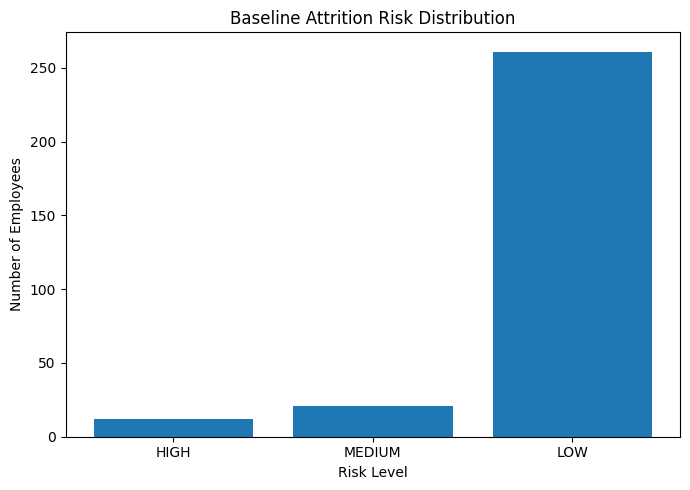

In [38]:
# ============================================================
# RISK DISTRIBUTION CHART
# ============================================================

plt.figure(figsize=(7, 5))

plt.bar(
    risk_distribution.index,
    risk_distribution["Employee Count"]
)

plt.title(
    "Baseline Attrition Risk Distribution"
)

plt.xlabel(
    "Risk Level"
)

plt.ylabel(
    "Number of Employees"
)

plt.tight_layout()

plt.show()

In [39]:
# ============================================================
# BASELINE MODEL SUMMARY
# ============================================================

baseline_summary = pd.DataFrame({
    "Model": [
        "Logistic Regression"
    ],
    
    "Training Rows": [
        len(X_train)
    ],
    
    "Testing Rows": [
        len(X_test)
    ],
    
    "Features Before Encoding": [
        len(available_features)
    ],
    
    "Precision": [
        round(baseline_precision, 4)
    ],
    
    "Recall": [
        round(baseline_recall, 4)
    ],
    
    "F1 Score": [
        round(baseline_f1, 4)
    ],
    
    "ROC-AUC": [
        round(baseline_roc_auc, 4)
    ]
})

print("BASELINE MODEL SUMMARY")
print("=" * 100)

display(baseline_summary)

BASELINE MODEL SUMMARY


,Model,Training Rows,Testing Rows,Features Before Encoding,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,1176,294,26,0.6296,0.3617,0.4595,0.8182


In [40]:
# ============================================================
# SAVE BASELINE MODEL
# ============================================================

import joblib

baseline_model_file = (
    MODEL_PATH /
    "baseline_attrition_pipeline.joblib"
)

joblib.dump(
    baseline_model,
    baseline_model_file
)

print("✓ Baseline model saved successfully.")

print(
    f"\nLocation:\n{baseline_model_file}"
)

✓ Baseline model saved successfully.

Location:
C:\Users\Shubham\Desktop\enterprise_hr_ai\models\baseline_attrition_pipeline.joblib


In [41]:
# ============================================================
# SAVE BASELINE PREDICTIONS
# ============================================================

PREDICTIONS_PATH = (
    PROJECT_ROOT /
    "data" /
    "predictions"
)

PREDICTIONS_PATH.mkdir(
    parents=True,
    exist_ok=True
)

prediction_file = (
    PREDICTIONS_PATH /
    "baseline_attrition_predictions.csv"
)

test_predictions.to_csv(
    prediction_file,
    index=False
)

print("✓ Baseline predictions saved successfully.")

print(
    f"\nLocation:\n{prediction_file}"
)

✓ Baseline predictions saved successfully.

Location:
C:\Users\Shubham\Desktop\enterprise_hr_ai\data\predictions\baseline_attrition_predictions.csv


In [42]:
# ============================================================
# SAVE BASELINE MODEL METRICS
# ============================================================

metrics_file = (
    MODEL_PATH /
    "baseline_model_metrics.csv"
)

baseline_summary.to_csv(
    metrics_file,
    index=False
)

print("✓ Baseline evaluation metrics saved.")

print(
    f"\nLocation:\n{metrics_file}"
)

✓ Baseline evaluation metrics saved.

Location:
C:\Users\Shubham\Desktop\enterprise_hr_ai\models\baseline_model_metrics.csv


In [43]:
# ============================================================
# VERIFY MODEL ARTIFACTS
# ============================================================

print("BASELINE MODEL ARTIFACTS")
print("=" * 70)

for file in sorted(
    MODEL_PATH.iterdir()
):
    
    if file.is_file():
        
        size_kb = (
            file.stat().st_size /
            1024
        )
        
        print(
            f"✓ {file.name} "
            f"({size_kb:.2f} KB)"
        )

print("\nPREDICTION FILES")
print("=" * 70)

for file in sorted(
    PREDICTIONS_PATH.glob("*.csv")
):
    
    size_kb = (
        file.stat().st_size /
        1024
    )
    
    print(
        f"✓ {file.name} "
        f"({size_kb:.2f} KB)"
    )

BASELINE MODEL ARTIFACTS
✓ baseline_attrition_pipeline.joblib (8.58 KB)
✓ baseline_model_metrics.csv (0.15 KB)

PREDICTION FILES
✓ baseline_attrition_predictions.csv (41.47 KB)


In [44]:
# ============================================================
# BASELINE MODEL COMPLETION STATUS
# ============================================================

print("BASELINE ATTRITION MODEL COMPLETED")
print("=" * 80)

print(
    "\n✓ Real employee attrition dataset used"
)

print(
    "✓ Target variable prepared"
)

print(
    "✓ Train/test split completed"
)

print(
    "✓ Preprocessing pipeline created"
)

print(
    "✓ Logistic Regression trained"
)

print(
    "✓ Precision calculated"
)

print(
    "✓ Recall calculated"
)

print(
    "✓ F1 Score calculated"
)

print(
    "✓ ROC-AUC calculated"
)

print(
    "✓ Confusion matrix generated"
)

print(
    "✓ Risk probabilities generated"
)

print(
    "✓ Baseline model saved"
)

print(
    "\nREADY FOR MODEL COMPARISON"
)

BASELINE ATTRITION MODEL COMPLETED

✓ Real employee attrition dataset used
✓ Target variable prepared
✓ Train/test split completed
✓ Preprocessing pipeline created
✓ Logistic Regression trained
✓ Precision calculated
✓ Recall calculated
✓ F1 Score calculated
✓ ROC-AUC calculated
✓ Confusion matrix generated
✓ Risk probabilities generated
✓ Baseline model saved

READY FOR MODEL COMPARISON
